tensor([[0.7729, 0.7988, 0.8291, 0.7964, 0.7271, 0.7310],
        [0.7666, 0.7988, 0.8330, 0.7852, 0.7310, 0.7134],
        [0.7769, 0.8081, 0.8452, 0.7915, 0.7520, 0.7349],
        [0.7827, 0.7734, 0.8018, 0.7871, 0.7246, 0.7021],
        [0.7207, 0.7539, 0.8408, 0.7549, 0.7119, 0.6934],
        [0.7510, 0.8364, 0.7671, 0.7827, 0.7554, 0.7637]])


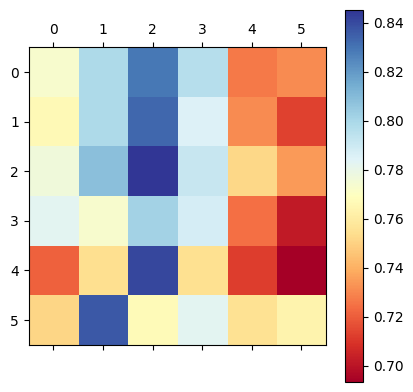

tensor(0.7799) tensor(0.7672) 0.012760460376739502


In [32]:
import torch
import clip
from PIL import Image
import matplotlib.pyplot as plt

from torchvision.transforms import Grayscale

import torch.nn.functional as F


device = "mps"

model, preprocess = clip.load("ViT-B/32", device=device)



# renders = [
#     "vis2/AespaStylizerSDS/blue_strokes/1780722100_render.png",
#     "vis2/AespaStylizerSDS/dark_matter_bw/1780721687_render.png",
#     "vis2/AespaStylizerSDS/fire/1780722495_render.png",
#     "vis2/AespaStylizerSDS/oil_crop/1780721334_render.png",
#     "vis2/AespaStylizerSDS/pattern1/1780723154_render.png",
#     "vis2/AespaStylizerSDS/volcano/1780722838_render.png",
# ]

renders = [
    "vis2/GatysStylizer/blue_strokes/1780724484_render.png",
    "vis2/GatysStylizer/dark_matter_bw/1780724392_render.png",
    "vis2/GatysStylizer/fire/1780724574_render.png",
    "vis2/GatysStylizer/oil_crop/1780724249_render.png",
    "vis2/GatysStylizer/pattern1/1780724916_render.png",
    "vis2/GatysStylizer/volcano/1780724738_render.png",
]

styles = [
    "data/style/good_ones/blue_strokes.jpg",
    "data/style/good_ones/dark_matter_bw.png",
    "data/style/good_ones/fire.png",
    "data/style/good_ones/oil_crop.jpg",
    "data/style/lame_ones/pattern1.png",
    "data/style/good_ones/volcano.png",
]

gray = Grayscale(3)

similarities = torch.zeros((len(styles), len(styles)))

for i,img in enumerate(renders):
    image1 = preprocess(Image.open(img)).unsqueeze(0).to(device)
    for j,style in enumerate(styles):
        image2 = preprocess(gray(Image.open(style))).unsqueeze(0).to(device)
        with torch.no_grad():
            image1_features = model.encode_image(image1)
            image2_features = model.encode_image(image2)
            
            # Normalize the features
            image1_features = F.normalize(image1_features, dim=-1)
            image2_features = F.normalize(image2_features, dim=-1)

            # Calculate cosine similarity
            similarities[i,j] = (image1_features @ image2_features.T).item()

# for c in range(len(styles)):
#     similarities[:,c] -= similarities[:,c].mean()

print(similarities)
plt.matshow(similarities, cmap="RdYlBu")
plt.colorbar()
plt.show()

diag_sim = (similarities * torch.eye(len(styles))).sum() / 6
off_diag_sim = (similarities * (1 - torch.eye(len(styles)))).sum() / 30

print(diag_sim, off_diag_sim, diag_sim.item() - off_diag_sim.item())

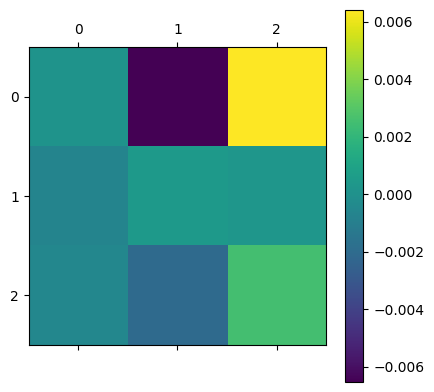

In [ ]:
import matplotlib.pyplot as plt

import torch
from torchvision.io import read_image
from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity
from torchvision.transforms import Resize, Grayscale

fire = read_image("data/style/good_ones/fire.png")
dark_matter = read_image("data/style/good_ones/dark_matter_bw.png")
starry = read_image("data/style/good_ones/starry.jpg")

fire_vol = read_image("report/fire-broken.jpg")
dark_matter_vol = read_image("report/dark-matter-bw-broken.png")
starry_vol = read_image("report/starry-broken.png")


imgs = [fire, dark_matter, starry]
vols = [fire_vol, dark_matter_vol, starry_vol]
# vols = imgs

lpips_metric = LearnedPerceptualImagePatchSimilarity("alex")
similarities = torch.zeros((len(imgs), len(vols)))

resize = Resize(fire_vol.shape[-2:])
gray = Grayscale(3)


for i,img in enumerate(imgs):
    img = gray(resize(img)).unsqueeze(0).to(torch.float32) / 255
    for j,vol in enumerate(vols):
        vol = gray(resize(vol)).unsqueeze(0).to(torch.float32) / 255
        similarities[i,j] = lpips_metric(img, vol)

# fig = plt.figure()
# ax = fig.add_subplot(111)
# cax = ax.matshow(similarities)
# fig.colorbar(cax)
# ax.

plt.matshow(similarities)
plt.colorbar()
plt.show()

